# Case Study
    Objective:
            1.Make the learner load the data using pandas.
            2.Create new columns in dataset from existing columns.
            3.Use pandas to answer questions of interest.
            4.Plot variables of interest.
            
            Dataset used:Prisoners dataset sourced from data.gov.in

## 1.Data Loading:
    a.Load the dataset “prisoners.csv” using pandas and display the first and last five rows in the dataset. 
            [Hint: Refer to read_csv,head and tail methods in pandas]
        
    b.Use describe method in pandas and find out the number of columns. 
    Can you say something about those rows who have zero inmates?
        [Hint: Use the loc attribute of dataframe combined with conditional checks]

In [16]:
import numpy as np
import pandas as pd

prison_df = pd.read_csv(r"..\Dataset\prisoners.csv")

print("1st 5 rows:")
print(prison_df.head())

print("last 5 rows:")
print(prison_df.tail())

1st 5 rows:
            STATE/UT  YEAR  No. of Inmates benefitted by Elementary Education  \
0     Andhra Pradesh  2013                                               9480   
1  Arunachal Pradesh  2013                                                  0   
2              Assam  2013                                                676   
3              Bihar  2013                                               1693   
4        Chhatisgarh  2013                                               1664   

   No. of Inmates benefitted by Adult Education  \
0                                         13758   
1                                             0   
2                                           750   
3                                          3013   
4                                          1803   

   No. of Inmates benefitted by Higher Education  \
0                                            672   
1                                              0   
2                                     

In [17]:
print(prison_df.describe())
# Looks like all 35 rows data of year 2013


         YEAR  No. of Inmates benefitted by Elementary Education  \
count    35.0                                          35.000000   
mean   2013.0                                        1057.914286   
std       0.0                                        2078.196777   
min    2013.0                                           0.000000   
25%    2013.0                                           0.000000   
50%    2013.0                                         167.000000   
75%    2013.0                                        1294.500000   
max    2013.0                                        9480.000000   

       No. of Inmates benefitted by Adult Education  \
count                                     35.000000   
mean                                    1534.857143   
std                                     3022.110503   
min                                        0.000000   
25%                                        6.500000   
50%                                      237.000000   
75

In [18]:
df = prison_df[(prison_df.loc[:,'No. of Inmates benefitted by Elementary Education'] == 0) | (prison_df.loc[:,'No. of Inmates benefitted by Adult Education'] == 0) 
              | (prison_df.loc[:,'No. of Inmates benefitted by Higher Education'] == 0) | (prison_df.loc[:,'No. of Inmates benefitted by Computer Course'] == 0) ]

df
#Conclusion: Below listed states less benifitted with education

,STATE/UT,YEAR,No. of Inmates benefitted by Elementary Education,No. of Inmates benefitted by Adult Education,No. of Inmates benefitted by Higher Education,No. of Inmates benefitted by Computer Course
1,Arunachal Pradesh,2013,0,0,0,0
5,Goa,2013,7,0,6,88
8,Himachal Pradesh,2013,33,80,26,0
15,Manipur,2013,0,0,0,0
16,Meghalaya,2013,1,30,0,0
17,Mizoram,2013,0,25,18,0
18,Nagaland,2013,0,0,0,0
22,Sikkim,2013,0,0,0,0
28,A & N Islands,2013,167,45,11,0
29,Chandigarh,2013,0,265,85,0


## 2.Data Manipulation:
    a.Create a new column -’total_benefitted’ that is a sum of inmates benefitted through all modes.
            [Hint: Use sum method with appropriate axis]
        
    b.Create a new row -“totals” that is the sum of all inmates benefitted through each mode across all states.

In [19]:
prison_df1 =prison_df
#Column addition, selecting only numeric fields
prison_df1['total_benefitted'] = prison_df1.iloc[:,2:7].sum(axis = 1)
#OR
#prisoners["total_benefited"]=prisoners.sum(axis=1)

#row addition, selecting only numeric fields
#Here sum(axis=0) we should not give with loc, it will add 2 new row, one as sum and another as totals
prison_df1.loc['totals'] = prison_df1.iloc[:,2:7].sum()
prison_df1

#row addition another way edu sol

#Method 2 edu sol
#prisoners_total = prison_df1.append(prison_df1.sum(numeric_only=True), ignore_index=True)


,STATE/UT,YEAR,No. of Inmates benefitted by Elementary Education,No. of Inmates benefitted by Adult Education,No. of Inmates benefitted by Higher Education,No. of Inmates benefitted by Computer Course,total_benefitted
0,Andhra Pradesh,2013.0,9480.0,13758.0,672.0,170.0,24080.0
1,Arunachal Pradesh,2013.0,0.0,0.0,0.0,0.0,0.0
2,Assam,2013.0,676.0,750.0,14.0,30.0,1470.0
3,Bihar,2013.0,1693.0,3013.0,125.0,1417.0,6248.0
4,Chhatisgarh,2013.0,1664.0,1803.0,192.0,103.0,3762.0
5,Goa,2013.0,7.0,0.0,6.0,88.0,101.0
6,Gujarat,2013.0,2310.0,3133.0,875.0,966.0,7284.0
7,Haryana,2013.0,1131.0,774.0,1112.0,243.0,3260.0
8,Himachal Pradesh,2013.0,33.0,80.0,26.0,0.0,139.0
9,Jammu & Kashmir,2013.0,102.0,124.0,33.0,34.0,293.0


## 3.Plotting:
         a.Make a bar plot with each state name on the x -axis and their total benefitted inmates as their bar heights. 
            Which state has the maximum number of beneficiaries?
        
            [Hint: Use bar method of pyplot] 
            
        b.Make a pie chart that depicts the ratio among different modes of benefits.
                [Hint: Use pie method of pyplot]


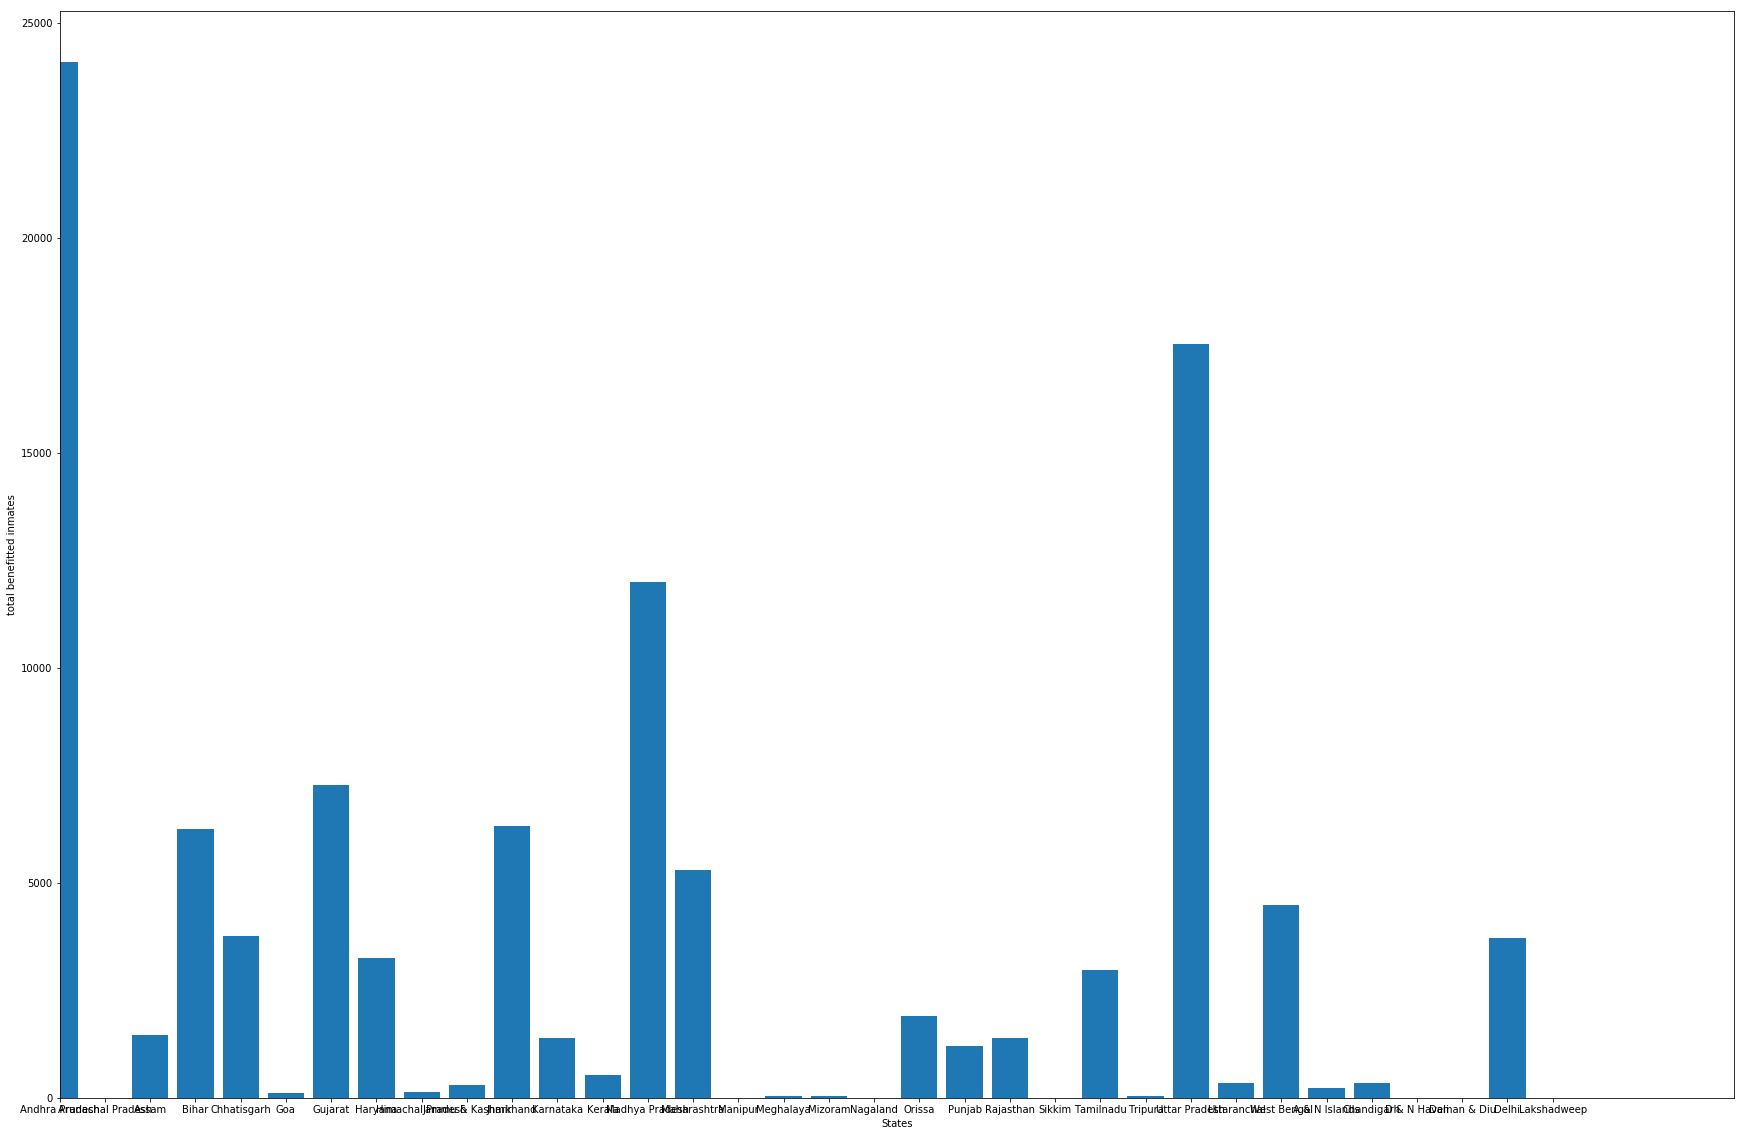

In [20]:
import matplotlib.pyplot as plt

#Method 1
x = prison_df1['STATE/UT'][:34]
y = prison_df1['total_benefitted'][:34]


#Fig/graph size can be changed
plt.figure(figsize=(30,20))
plt.bar(x,y)
plt.xlim(0,37)
plt.xlabel("States")
plt.ylabel("total benefitted inmates")
plt.show()

['Andhra Pradesh' 'Arunachal Pradesh' 'Assam' 'Bihar' 'Chhatisgarh' 'Goa'
 'Gujarat' 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand'
 'Karnataka' 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Manipur' 'Meghalaya'
 'Mizoram' 'Nagaland' 'Orissa' 'Punjab' 'Rajasthan' 'Sikkim' 'Tamilnadu'
 'Tripura' 'Uttar Pradesh' 'Uttaranchal' 'West Bengal' 'A & N Islands'
 'Chandigarh' 'D & N Haveli' 'Daman & Diu' 'Delhi' 'Lakshadweep'
 'Pondicherry' nan]
36
36
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35]


<BarContainer object of 36 artists>

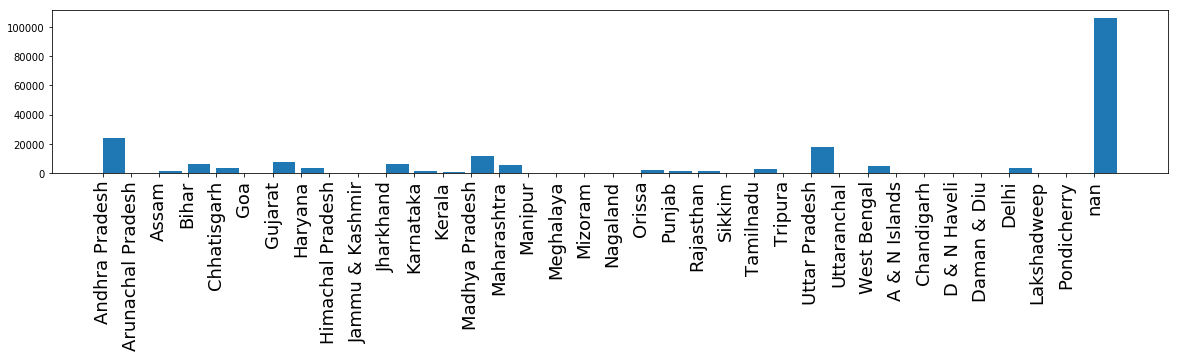

In [21]:
#Method 2 , to make country name visible
#Edu sol


xlabels = prison_df1['STATE/UT'].values
print(xlabels)
print(xlabels.shape[0])
print(prison_df1.values.shape[0])
print(np.arange(prison_df1.values.shape[0]))

plt.figure(figsize=(20, 3))
#here 1st 0-35 integer assigned with corresponding  xlabels, rotation='vertical'
plt.xticks(np.arange(xlabels.shape[0]),xlabels,rotation='vertical', fontsize=18)

plt.xticks

plt.bar(np.arange(prison_df1.values.shape[0]),prison_df1['total_benefitted'],align='edge')

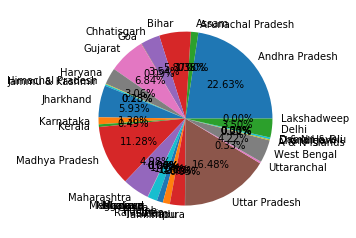

In [22]:
# b.Make a pie chart that depicts the ratio among different modes of benefits.
           # [Hint: Use pie method of pyplot]

#This is not actual result, this is ratio among states wise total_benefitted
my_label = prison_df1['STATE/UT'][:34]
data = prison_df1['total_benefitted'][:34]

plt.pie(data,labels = my_label, autopct='%1.2f%%')
plt.show()

No. of Inmates benefitted by Elementary Education    37027
No. of Inmates benefitted by Adult Education         53720
No. of Inmates benefitted by Higher Education         8311
No. of Inmates benefitted by Computer Course          7356
Name: totals, dtype: object
Index(['No. of Inmates benefitted by Elementary Education',
       'No. of Inmates benefitted by Adult Education',
       'No. of Inmates benefitted by Higher Education',
       'No. of Inmates benefitted by Computer Course'],
      dtype='object')
[37027.0 53720.0 8311.0 7356.0]


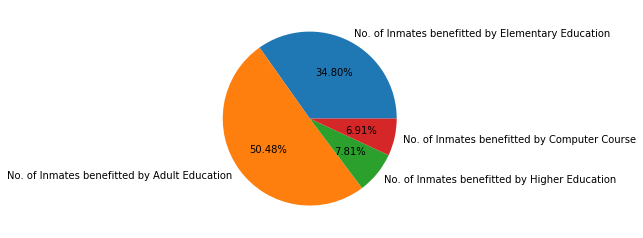

In [24]:
print(prison_df1.iloc[-1, 2:6])
my_label = prison_df1.iloc[-1, 2:6].index
data = prison_df1.iloc[-1, 2:6].values
print(my_label)
print(data)



plt.pie(data,labels = my_label, autopct='%1.2f%%')
plt.show()

Index(['STATE/UT', 'YEAR', 'No. of Inmates benefitted by Elementary Education',
       'No. of Inmates benefitted by Adult Education',
       'No. of Inmates benefitted by Higher Education',
       'No. of Inmates benefitted by Computer Course', 'total_benefitted'],
      dtype='object')
*************************
Index(['No. of Inmates benefitted by Elementary Education',
       'No. of Inmates benefitted by Adult Education',
       'No. of Inmates benefitted by Higher Education',
       'No. of Inmates benefitted by Computer Course'],
      dtype='object')
[37027.0 53720.0 8311.0 7356.0]


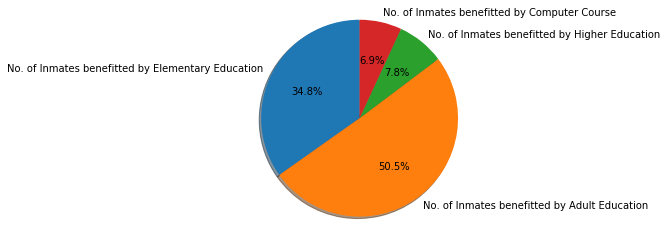

In [25]:
#Another way
print(prison_df1.columns)
print("*************************")
labels = prison_df1.columns[2:-1]
sizes = prison_df1.iloc[-1][2:-1].values
print(labels)
print(sizes)
fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.show()